### Imports

In [1]:
import os
import sys

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [3]:
import frank2d
from frank2d import Frank2D, Geometry, rad_to_arcsec, Plot

### Load data

In [6]:

dir = "../../data/uvtable/"
disk_name = "SimulatedBlob"
data_file = dir +"uvtable_SimulatedBlob.txt"

inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack =True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }


In [7]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


#### Power spectrum

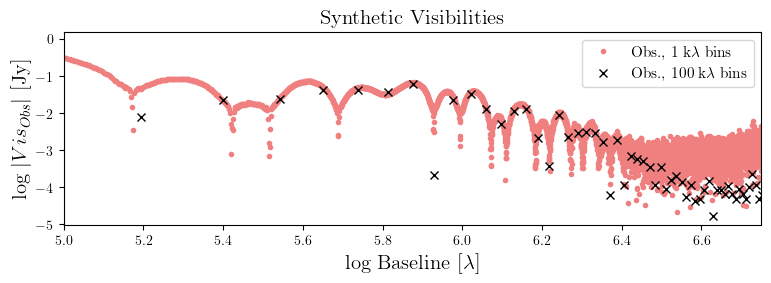

In [38]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V))

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V))


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 2.5))
plt.plot(logx, logy, marker=ms[0], ls='None', c ='lightcoral', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.xlabel(r'log Baseline [$\lambda$]', size=15)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size=15)
plt.legend(loc = 'best', fontsize=11)
plt.title("Synthetic Visibilities", size=15)
plt.xlim(5, 6.75)
plt.show()

### Gridded Visibilities

In [9]:
frank2d0 = Frank2D(N, Rmax, use_gpu=True)

In [10]:
frank2d0.dx

0.009345794392523364

In [11]:
q_min_f2d = np.unique(np.sort(np.hypot(frank2d0.u, frank2d0.v)))[1]
q_max_f2d = np.unique(np.sort(np.hypot(frank2d0.u, frank2d0.v)))[-1]
print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min frank2d: 48617.081072483736, q_max frank2d: 15606083.024267279
-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [12]:
np.sort(frank2d0.FT.q)

array([       0.        ,    34377.46770785,    34377.46770785, ...,
       15581793.44513957, 15581793.44513957, 15606083.02426728],
      shape=(412164,))

In [13]:
frank2d0.process_vis(uvtable)

===>  Setting gridded data...


In [14]:
u, v = frank2d0.gridded_data['u'].get(), frank2d0.gridded_data['v'].get()
vis = frank2d0.gridded_data['vis'].get()
weights = frank2d0.gridded_data['weights']

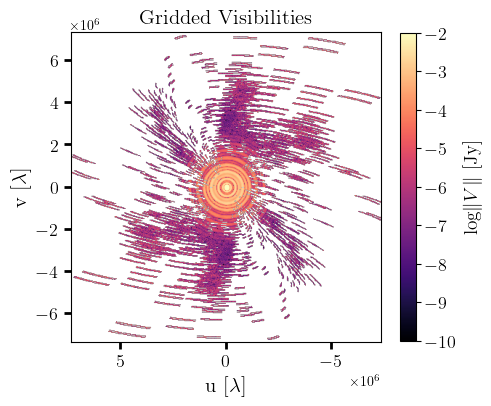

In [24]:
zoom_factor = 1.5

plt.figure(figsize=(5,5))
plt.imshow(np.log(np.abs(vis.reshape(N,N))), 
            extent = [u.max(), u.min(), v.min(), v.max()],
            cmap = 'magma', 
             vmin=-10, vmax=-2)
plt.title('Gridded Visibilities', size=15)
plt.ylim(v.min()/zoom_factor, v.max()/zoom_factor)
plt.xlim(u.max()/zoom_factor, u.min()/zoom_factor)
plt.xlabel(r'u [$\lambda$]', size=15, weight='extra bold')
plt.ylabel(r'v [$\lambda$]', size=15, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(r'log$\| V \|$ [Jy]', size=14)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)
plt.show()

### Dirty Image

In [19]:
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
pixel_area_in_sr = dx * dy
I_syn_full_Jy_per_sr = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis.reshape(N,N)))).real / pixel_area_in_sr
I_syn_full_Jy_per_pixel = I_syn_full_Jy_per_sr * pixel_area_in_sr

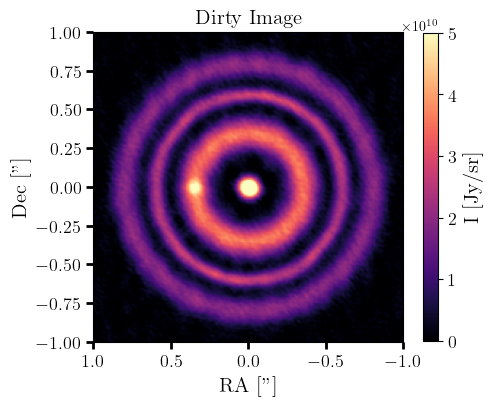

In [25]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 1, vmax=5e10, vmin = 0)
plt.figure(figsize=(5,5))
plt.imshow(
            I_syn_full_Jy_per_sr, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma',
            )

plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
plt.title('Dirty Image', size=15)
plt.xlabel('RA ["]', size=15, weight='extra bold')
plt.ylabel('Dec ["]', size=15, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(label='I [Jy/sr]', size=15)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)